In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['Species'] = iris.target
df['Species'] = df['Species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [5]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000      

In [6]:
label_encoder = LabelEncoder()

df['Species_Label'] = label_encoder.fit_transform(df['Species'])

df[['Species', 'Species_Label']].head()

,Species,Species_Label
0,Setosa,0
1,Setosa,0
2,Setosa,0
3,Setosa,0
4,Setosa,0


In [7]:
label_encoder = LabelEncoder()

df['Species_Label'] = label_encoder.fit_transform(df['Species'])

df[['Species', 'Species_Label']].head()

,Species,Species_Label
0,Setosa,0
1,Setosa,0
2,Setosa,0
3,Setosa,0
4,Setosa,0


In [8]:
onehot_df = pd.get_dummies(df, columns=['Species'])

onehot_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species_Label,Species_Setosa,Species_Versicolor,Species_Virginica
0,5.1,3.5,1.4,0.2,0,True,False,False
1,4.9,3.0,1.4,0.2,0,True,False,False
2,4.7,3.2,1.3,0.2,0,True,False,False
3,4.6,3.1,1.5,0.2,0,True,False,False
4,5.0,3.6,1.4,0.2,0,True,False,False


In [9]:
df['Plant_Size'] = ['Small']*50 + ['Medium']*50 + ['Large']*50

ordinal = OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])

df['Plant_Size_Encoded'] = ordinal.fit_transform(df[['Plant_Size']])

df[['Plant_Size', 'Plant_Size_Encoded']].head()

,Plant_Size,Plant_Size_Encoded
0,Small,0.0
1,Small,0.0
2,Small,0.0
3,Small,0.0
4,Small,0.0


In [10]:
X = df.iloc[:, 0:4]

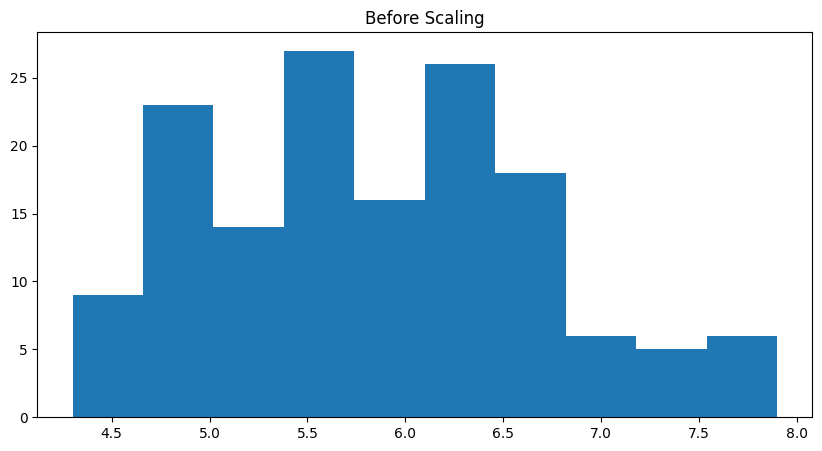

In [11]:
plt.figure(figsize=(10,5))

plt.hist(X['sepal length (cm)'])
plt.title("Before Scaling")
plt.show()

In [12]:
standard = StandardScaler()

X_standard = pd.DataFrame(
    standard.fit_transform(X),
    columns=X.columns
)

X_standard.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


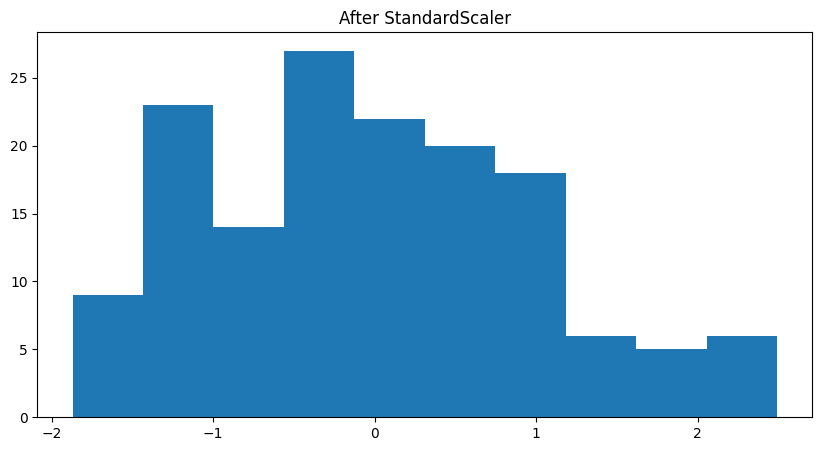

In [13]:
plt.figure(figsize=(10,5))

plt.hist(X_standard['sepal length (cm)'])
plt.title("After StandardScaler")
plt.show()

In [14]:
minmax = MinMaxScaler()

X_minmax = pd.DataFrame(
    minmax.fit_transform(X),
    columns=X.columns
)

X_minmax.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [15]:
robust = RobustScaler()

X_robust = pd.DataFrame(
    robust.fit_transform(X),
    columns=X.columns
)

X_robust.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.538462,1.0,-0.842857,-0.733333
1,-0.692308,0.0,-0.842857,-0.733333
2,-0.846154,0.4,-0.871429,-0.733333
3,-0.923077,0.2,-0.814286,-0.733333
4,-0.615385,1.2,-0.842857,-0.733333


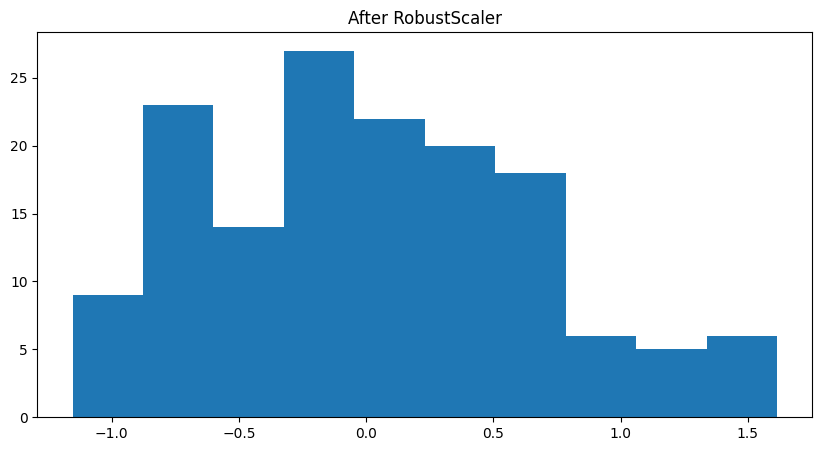

In [16]:
plt.figure(figsize=(10,5))

plt.hist(X_robust['sepal length (cm)'])
plt.title("After RobustScaler")
plt.show()

In [18]:
X = df.iloc[:, 0:4]

y = df['Species_Label']

In [19]:
selector = SelectKBest(score_func=f_classif, k=4)

X_new = selector.fit_transform(X, y)

In [20]:
scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

scores = scores.sort_values(by='Score', ascending=False)

print(scores)

             Feature        Score
2  petal length (cm)  1180.161182
3   petal width (cm)   960.007147
0  sepal length (cm)   119.264502
1   sepal width (cm)    49.160040


In [21]:
print("Top Features:")
print(scores.head())

Top Features:
             Feature        Score
2  petal length (cm)  1180.161182
3   petal width (cm)   960.007147
0  sepal length (cm)   119.264502
1   sepal width (cm)    49.160040
